In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
from pandas import read_csv
from matplotlib import pyplot

time_series=pd.date_range("2022-01-01", "2022-01-02", freq="5 min")
data=pd.Series(range(len(time_series)), index=time_series)
print(data)

2022-01-01 00:00:00      0
2022-01-01 00:05:00      1
2022-01-01 00:10:00      2
2022-01-01 00:15:00      3
2022-01-01 00:20:00      4
                      ... 
2022-01-01 23:40:00    284
2022-01-01 23:45:00    285
2022-01-01 23:50:00    286
2022-01-01 23:55:00    287
2022-01-02 00:00:00    288
Freq: 5T, Length: 289, dtype: int64


In [10]:
#upsampling data
upsampled_data=data.resample("1min").asfreq()
print(upsampled_data)

2022-01-01 00:00:00      0.0
2022-01-01 00:01:00      NaN
2022-01-01 00:02:00      NaN
2022-01-01 00:03:00      NaN
2022-01-01 00:04:00      NaN
                       ...  
2022-01-01 23:56:00      NaN
2022-01-01 23:57:00      NaN
2022-01-01 23:58:00      NaN
2022-01-01 23:59:00      NaN
2022-01-02 00:00:00    288.0
Freq: T, Length: 1441, dtype: float64


In [11]:
#downsampling data
downsampled_data=data.resample("5min").asfreq()
print(downsampled_data)

2022-01-01 00:00:00      0
2022-01-01 00:05:00      1
2022-01-01 00:10:00      2
2022-01-01 00:15:00      3
2022-01-01 00:20:00      4
                      ... 
2022-01-01 23:40:00    284
2022-01-01 23:45:00    285
2022-01-01 23:50:00    286
2022-01-01 23:55:00    287
2022-01-02 00:00:00    288
Freq: 5T, Length: 289, dtype: int64


In [12]:
date_range=pd.date_range(start="2022-01-01", end="2022-12-31", freq="D")
date_range

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2022-12-22', '2022-12-23', '2022-12-24', '2022-12-25',
               '2022-12-26', '2022-12-27', '2022-12-28', '2022-12-29',
               '2022-12-30', '2022-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

In [13]:
temp_data=np.random.normal(loc=10, scale=5, size=len(date_range))
temp_data

array([16.96566663,  5.8993788 ,  5.70717363,  9.96026228,  2.52251868,
        2.51532033, 10.10270808, 17.92999254,  5.19026006, 13.46253102,
       14.52367315,  8.67013688, 10.63343124,  7.70094889,  4.78722176,
       15.97821016, 16.05311336, 11.94135843,  0.17321879, 16.74967747,
        6.65558252,  2.60878247,  8.12931446,  7.61406765,  4.5507099 ,
        4.62654585, 16.43987936,  6.48895341, 14.00571777, 15.98174978,
        4.36017828, 14.2654367 ,  6.64971623, 14.29040105, 13.18876321,
        9.91659431, 10.78529552,  8.32211783, 12.62739892,  9.49281499,
       12.23280818, 11.7116723 ,  3.780124  , 15.74185713, 10.24421032,
        6.07778014, 14.46234248, 12.95764085,  4.23226293,  6.20585931,
       -0.4682574 , 10.47496838, 10.35854547, 10.76707488, 13.31117311,
       22.53969073, 20.32960215,  3.05906642,  8.89211402, 16.07129707,
       -0.29386144,  3.57713447, 17.87319952, 16.56602377,  7.33495173,
        3.72119086,  9.13633075, 10.99037784, 19.65906126,  4.65

In [15]:
df=pd.DataFrame({"Date":date_range, "Temperature":temp_data})
df.head()

,Date,Temperature
0,2022-01-01,16.965667
1,2022-01-02,5.899379
2,2022-01-03,5.707174
3,2022-01-04,9.960262
4,2022-01-05,2.522519


In [16]:
df.set_index("Date", inplace=True)
df.head()

,Temperature
Date,
2022-01-01,16.965667
2022-01-02,5.899379
2022-01-03,5.707174
2022-01-04,9.960262
2022-01-05,2.522519


<Axes: xlabel='Date'>

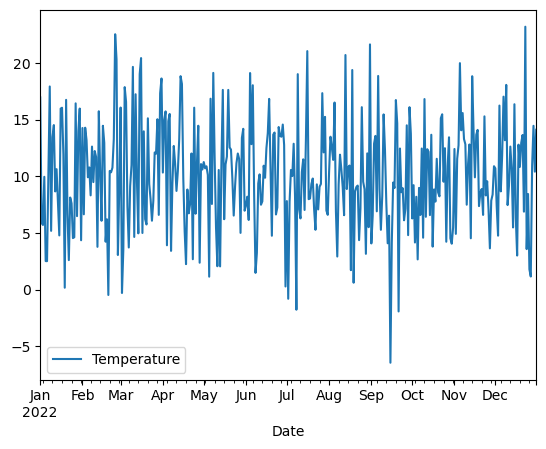

In [17]:
df.plot()

In [18]:
df.head()

,Temperature
Date,
2022-01-01,16.965667
2022-01-02,5.899379
2022-01-03,5.707174
2022-01-04,9.960262
2022-01-05,2.522519


In [19]:
df.tail()

,Temperature
Date,
2022-12-27,1.161153
2022-12-28,10.975054
2022-12-29,14.458460
2022-12-30,10.413353
2022-12-31,14.116070


C:\Users\admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


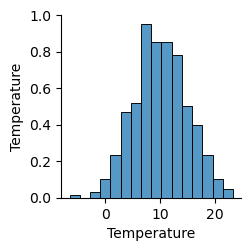

In [20]:
sns.pairplot(df)

In [29]:
upsampled=df.resample("D")
interpolated=upsampled.interpolate(method="linear")
print(interpolated.head(10))

            Temperature
Date                   
2022-01-01    16.965667
2022-01-02     5.899379
2022-01-03     5.707174
2022-01-04     9.960262
2022-01-05     2.522519
2022-01-06     2.515320
2022-01-07    10.102708
2022-01-08    17.929993
2022-01-09     5.190260
2022-01-10    13.462531


In [30]:
interpolated=upsampled.interpolate(method="spline", order=2)
print(interpolated.head(10))

            Temperature
Date                   
2022-01-01    16.965667
2022-01-02     5.899379
2022-01-03     5.707174
2022-01-04     9.960262
2022-01-05     2.522519
2022-01-06     2.515320
2022-01-07    10.102708
2022-01-08    17.929993
2022-01-09     5.190260
2022-01-10    13.462531


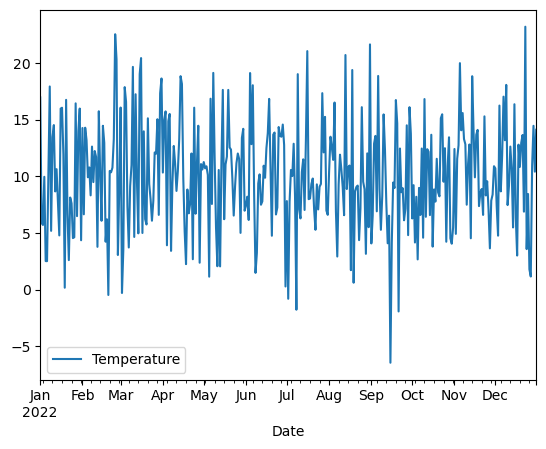

In [31]:
interpolated.plot()
pyplot.show()

In [34]:
resample=df.resample('Q')
quarterly_mean_temp=resample.mean()
print(quarterly_mean_temp.head())

            Temperature
Date                   
2022-03-31    10.275632
2022-06-30    10.309940
2022-09-30     9.460747
2022-12-31    10.064771


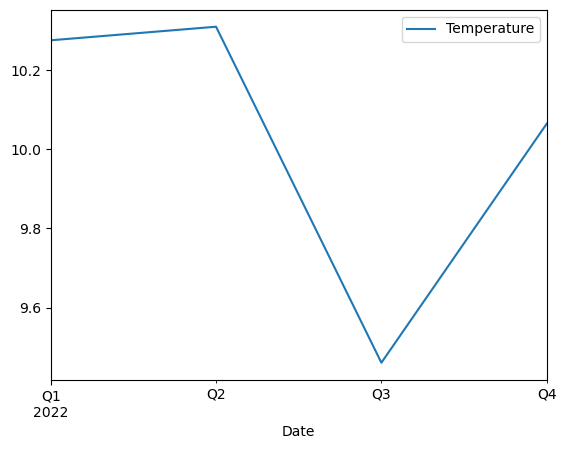

In [35]:
quarterly_mean_temp.plot()
pyplot.show()

In [39]:
resample=df.resample("A")
quarterly_mean_temp=resample.sum()
print(quarterly_mean_temp)

            Temperature
Date                   
2022-12-31    3659.3591


C:\Users\admin\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1409: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


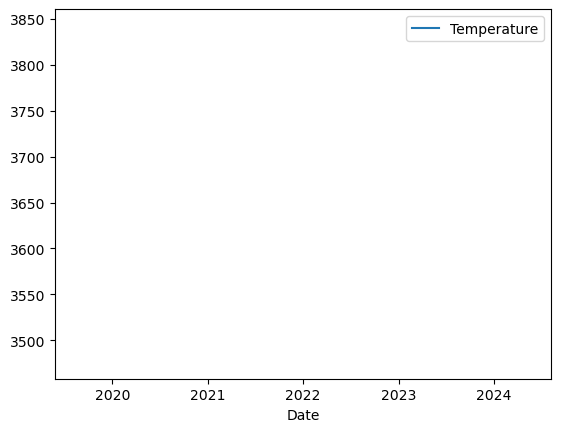

In [40]:
quarterly_mean_temp.plot()
pyplot.show()